In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, roc_auc_score
)

In [3]:
diabetes = load_diabetes()

X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y_original = diabetes.target

print(X.head())
print(X.shape)
print(X.describe())

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  
(442, 10)
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072256e-01

In [4]:
threshold = np.median(y_original)

y = (y_original >= threshold).astype(int)

print("Threshold:", threshold)
print("Class distribution:")
print(pd.Series(y).value_counts())

Threshold: 140.5
Class distribution:
1    221
0    221
Name: count, dtype: int64


In [5]:
df = X.copy()
df["diagnosis"] = y

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,diagnosis
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,1
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,1
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,1
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,0


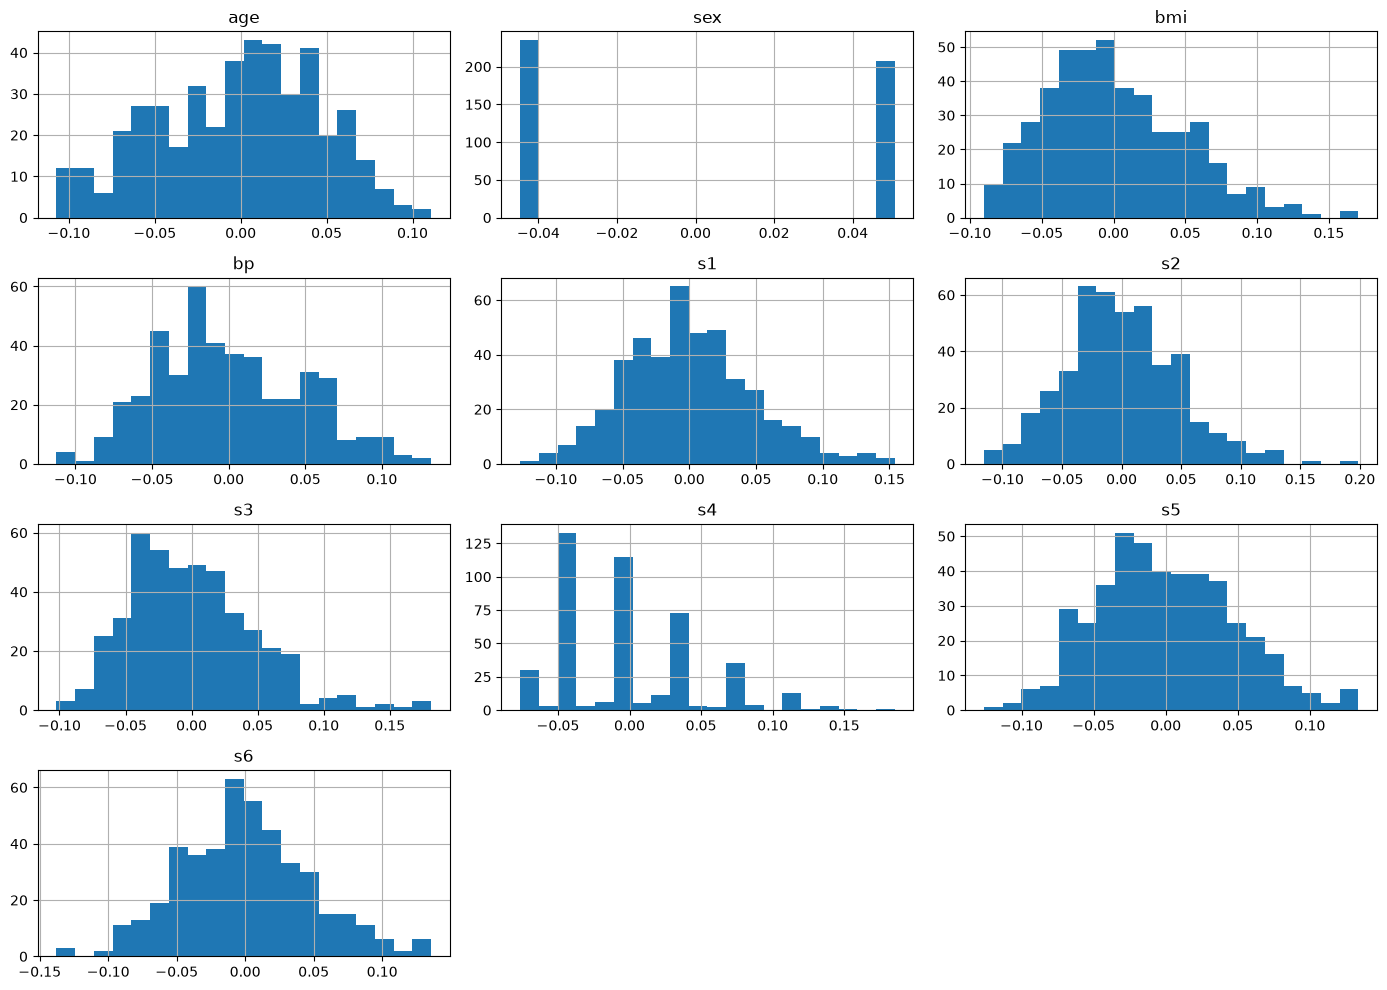

In [6]:
X.hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.show()

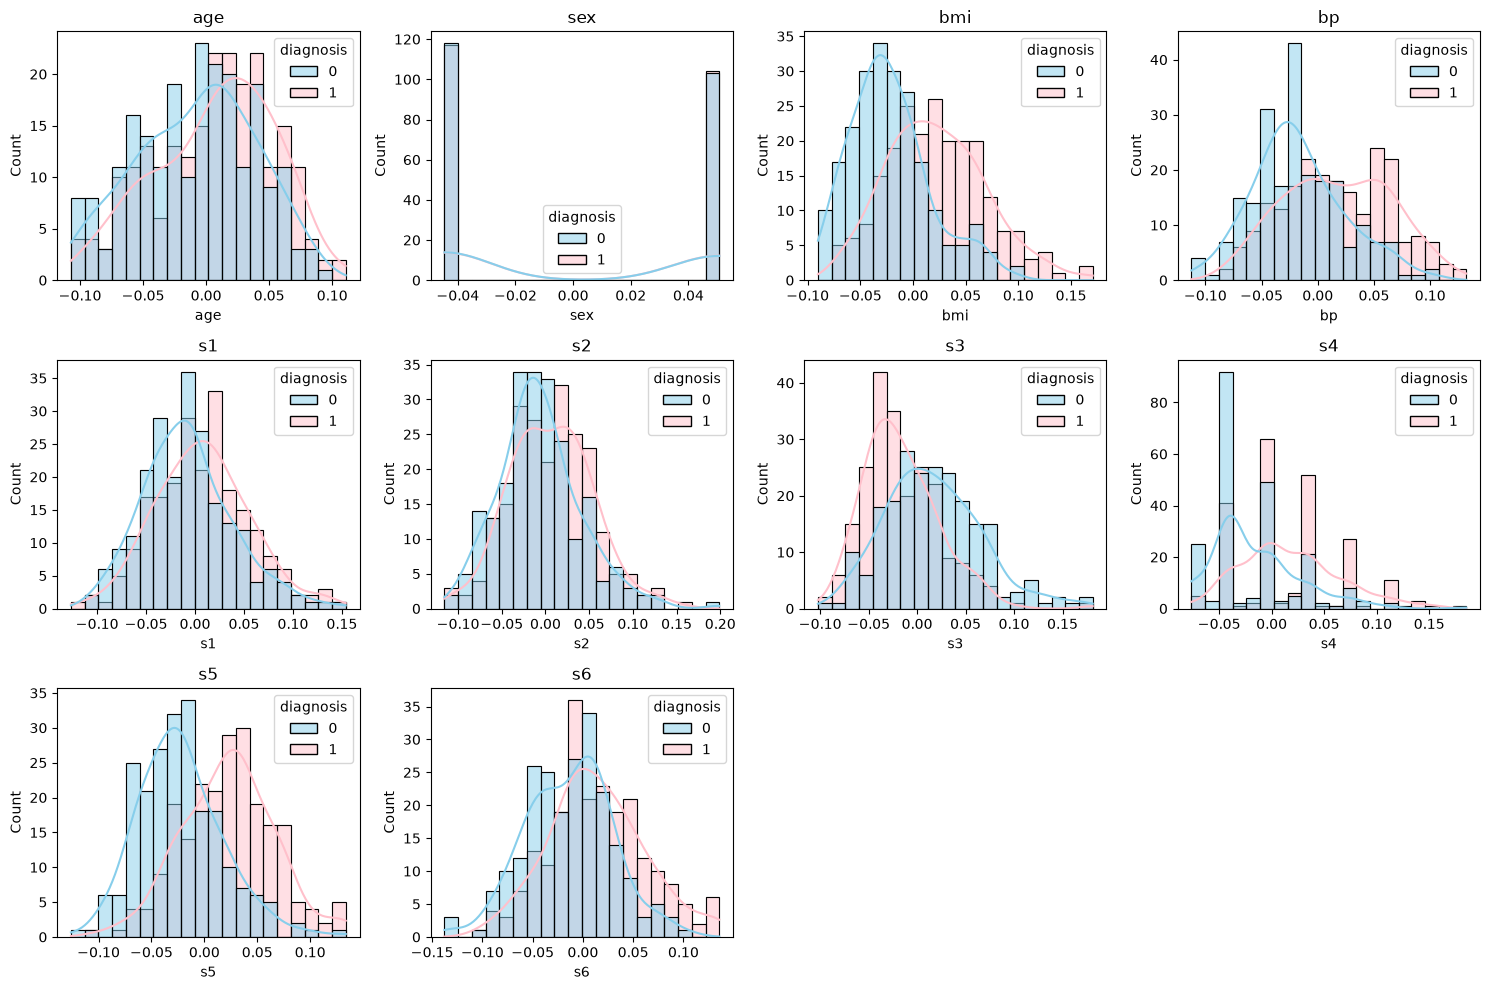

In [7]:
fig, axes = plt.subplots(3, 4, figsize=(15, 10))  
  
for i, feature in enumerate(X.columns):  
    ax = axes[i // 4, i % 4]  
      
    sns.histplot(  
        data=df,  
        x=feature,  
        hue="diagnosis",  
        bins=20,  
        kde=True,  
        ax=ax, 
        palette=["skyblue", "pink"] 
    )  
      
    ax.set_title(feature)  

# Hide the 2 unused boxes
for j in range(len(X.columns), len(axes.flat)):
    axes.flat[j].set_visible(False)

plt.tight_layout()  
plt.show()

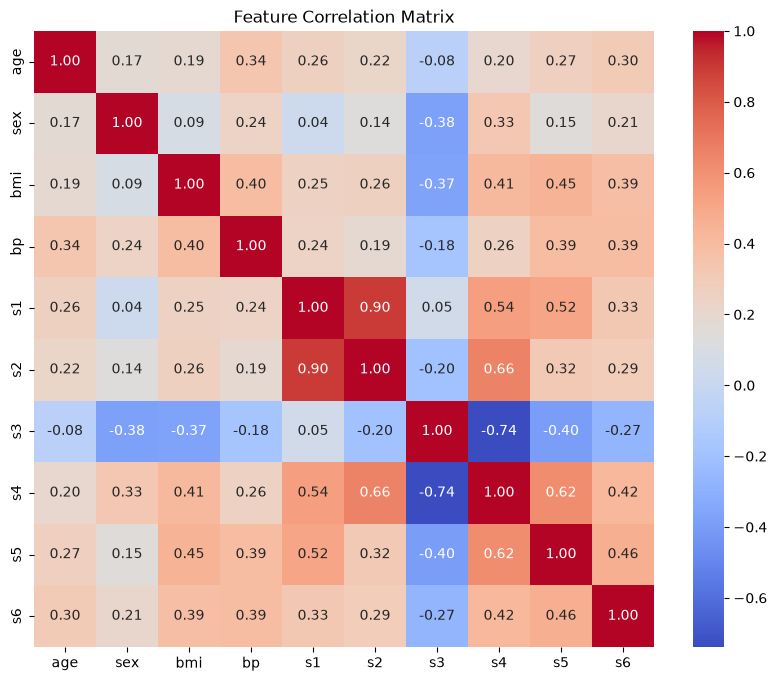

In [8]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    X.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")
plt.show()

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
def multivariate_gaussian(x, mean, covariance):
    x = np.asarray(x)
    mean = np.asarray(mean)
    
    d = len(mean)
    
    coefficient = 1 / (
        (2 * np.pi) ** (d / 2) *
        np.sqrt(np.linalg.det(covariance))
    )
    
    exponent = -0.5 * (
        (x - mean).T @
        np.linalg.inv(covariance) @
        (x - mean)
    )
    
    return coefficient * np.exp(exponent)

In [12]:
mean = np.array([0, 0])

covariance = np.array([
    [1, 0],
    [0, 1]
])

point = np.array([0, 0])

print(multivariate_gaussian(point, mean, covariance))

0.15915494309189535


In [13]:
x = np.linspace(-4, 4, 100)
y_grid = np.linspace(-4, 4, 100)

X_grid, Y_grid = np.meshgrid(x, y_grid)

points = np.dstack((X_grid, Y_grid))

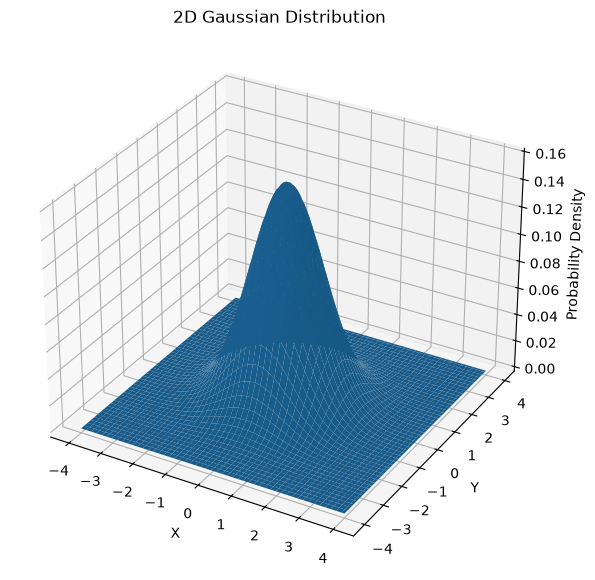

In [14]:
mean = np.array([0, 0])

covariance = np.array([
    [1, 0],
    [0, 1]
])

Z = np.zeros(X_grid.shape)

for i in range(X_grid.shape[0]):
    for j in range(X_grid.shape[1]):
        Z[i, j] = multivariate_gaussian(
            points[i, j],
            mean,
            covariance
        )

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(X_grid, Y_grid, Z)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Probability Density")
ax.set_title("2D Gaussian Distribution")

plt.show()

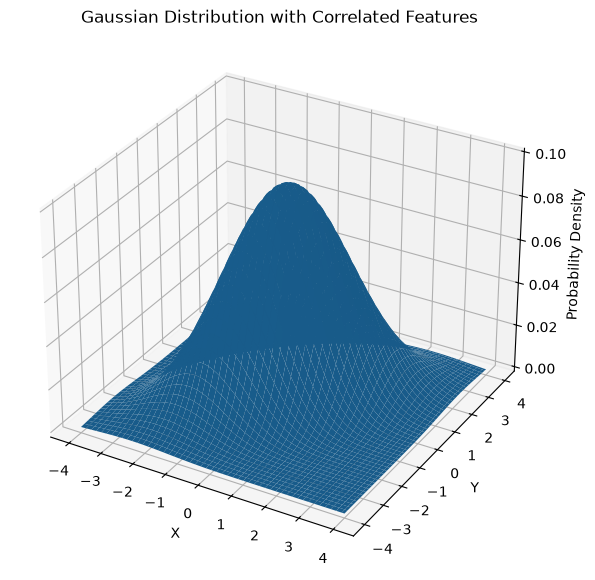

In [15]:
mean = np.array([0, 0])

covariance = np.array([
    [2, 1.2],
    [1.2, 2]
])

Z = np.zeros(X_grid.shape)

for i in range(X_grid.shape[0]):
    for j in range(X_grid.shape[1]):
        Z[i, j] = multivariate_gaussian(
            points[i, j],
            mean,
            covariance
        )

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(X_grid, Y_grid, Z)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Probability Density")
ax.set_title("Gaussian Distribution with Correlated Features")

plt.show()

In [16]:
class_0 = X_train_scaled[y_train == 0]
class_1 = X_train_scaled[y_train == 1]

mean_0 = np.mean(class_0, axis=0)
mean_1 = np.mean(class_1, axis=0)

cov_0 = np.cov(class_0, rowvar=False)
cov_1 = np.cov(class_1, rowvar=False)

n0 = len(class_0)
n1 = len(class_1)

pooled_cov = (
    (n0 - 1) * cov_0 +
    (n1 - 1) * cov_1
) / (n0 + n1 - 2)

print("Mean of class 0:")
print(mean_0)

print("\nMean of class 1:")
print(mean_1)

print("\nPooled covariance:")
print(pooled_cov)

Mean of class 0:
[-0.16190075 -0.00878581 -0.48338764 -0.41144274 -0.16263431 -0.14495921
  0.32548083 -0.33712705 -0.45262747 -0.27366497]

Mean of class 1:
[ 0.16098605  0.00873618  0.48065664  0.40911821  0.16171547  0.14414023
 -0.32364195  0.33522238  0.45007026  0.27211884]

Pooled covariance:
[[ 0.97948573  0.16546023  0.13793375  0.24827196  0.2592485   0.22128233
  -0.01569742  0.16604791  0.20726199  0.23666007]
 [ 0.16546023  1.00562081  0.09041462  0.2372841  -0.0248495   0.10335257
  -0.38856593  0.3062366   0.09726733  0.191903  ]
 [ 0.13793375  0.09041462  0.77203063  0.25402957  0.21670342  0.25267837
  -0.21343596  0.28478333  0.23277162  0.27556308]
 [ 0.24827196  0.2372841   0.25402957  0.83641015  0.2045433   0.15119645
  -0.03181634  0.12091652  0.22112493  0.31436397]
 [ 0.2592485  -0.0248495   0.21670342  0.2045433   0.97924766  0.87425816
   0.10815419  0.48731476  0.46088921  0.28203145]
 [ 0.22128233  0.10335257  0.25267837  0.15119645  0.87425816  0.98468449


In [17]:
prior_0 = n0 / (n0 + n1)
prior_1 = n1 / (n0 + n1)

cov_inv = np.linalg.inv(pooled_cov)

def lda_score(x, mean, prior):
    return (
        x @ cov_inv @ mean
        - 0.5 * mean @ cov_inv @ mean
        + np.log(prior)
    )

In [18]:
def lda_predict(X):
    predictions = []
    
    for x in X:
        score_0 = lda_score(x, mean_0, prior_0)
        score_1 = lda_score(x, mean_1, prior_1)
        
        if score_1 > score_0:
            predictions.append(1)
        else:
            predictions.append(0)
    
    return np.array(predictions)

In [19]:
y_pred_lda_manual = lda_predict(X_test_scaled)

print("Manual LDA Accuracy:",
      accuracy_score(y_test, y_pred_lda_manual))

Manual LDA Accuracy: 0.7303370786516854


In [20]:
lda = LinearDiscriminantAnalysis()

lda.fit(X_train_scaled, y_train)

y_pred_lda = lda.predict(X_test_scaled)
y_prob_lda = lda.predict_proba(X_test_scaled)[:, 1]

print("LDA Accuracy:", accuracy_score(y_test, y_pred_lda))

LDA Accuracy: 0.7303370786516854


In [21]:
print(classification_report(y_test, y_pred_lda))

              precision    recall  f1-score   support

           0       0.76      0.69      0.72        45
           1       0.71      0.77      0.74        44

    accuracy                           0.73        89
   macro avg       0.73      0.73      0.73        89
weighted avg       0.73      0.73      0.73        89



In [22]:
X_2d = X_train_scaled[:, :2]

lda_2d = LinearDiscriminantAnalysis()

lda_2d.fit(X_2d, y_train)

x_min = X_2d[:, 0].min() - 1
x_max = X_2d[:, 0].max() + 1

y_min = X_2d[:, 1].min() - 1
y_max = X_2d[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]

Z = lda_2d.predict(grid)

Z = Z.reshape(xx.shape)

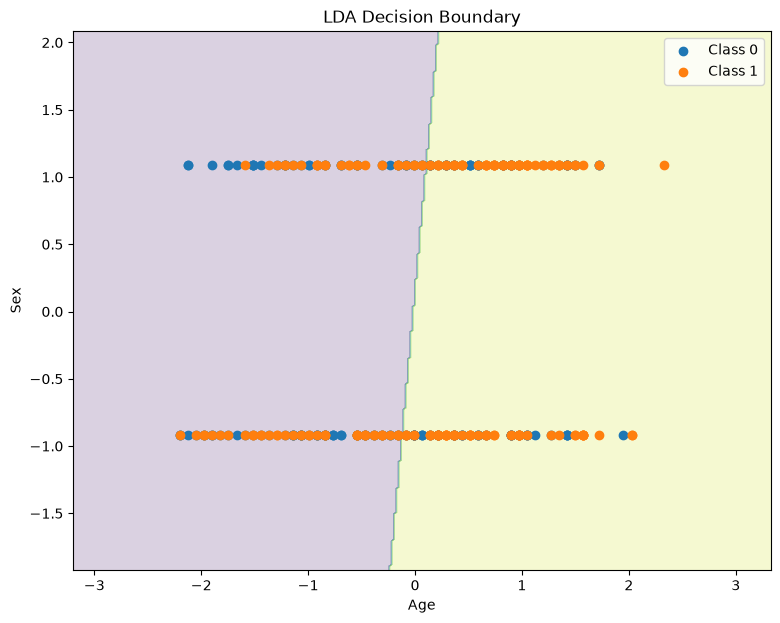

In [23]:
plt.figure(figsize=(9, 7))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.2
)

plt.scatter(
    X_2d[y_train == 0, 0],
    X_2d[y_train == 0, 1],
    label="Class 0"
)

plt.scatter(
    X_2d[y_train == 1, 0],
    X_2d[y_train == 1, 1],
    label="Class 1"
)

plt.xlabel("Age")
plt.ylabel("Sex")
plt.title("LDA Decision Boundary")
plt.legend()

plt.show()

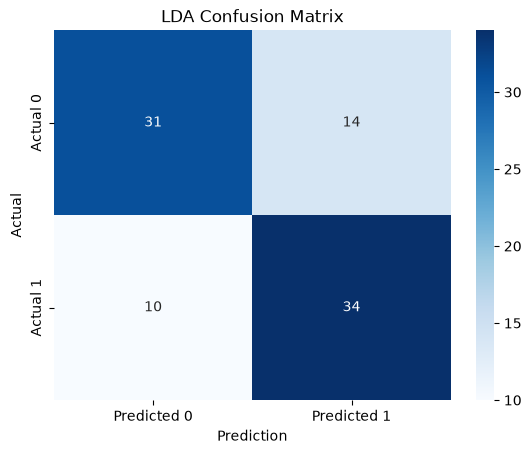

In [24]:
cm = confusion_matrix(y_test, y_pred_lda)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Actual 0", "Actual 1"]
)

plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title("LDA Confusion Matrix")

plt.show()

In [25]:
accuracy = accuracy_score(y_test, y_pred_lda)
precision = precision_score(y_test, y_pred_lda)
recall = recall_score(y_test, y_pred_lda)
f1 = f1_score(y_test, y_pred_lda)
auc = roc_auc_score(y_test, y_prob_lda)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", auc)

Accuracy : 0.7303370786516854
Precision: 0.7083333333333334
Recall   : 0.7727272727272727
F1 Score : 0.7391304347826086
ROC-AUC  : 0.8287878787878789


In [26]:
threshold = 0.30

y_pred_medical = (y_prob_lda >= threshold).astype(int)

print(confusion_matrix(y_test, y_pred_medical))

[[27 18]
 [ 6 38]]


In [27]:
print("Accuracy :", accuracy_score(y_test, y_pred_medical))
print("Precision:", precision_score(y_test, y_pred_medical))
print("Recall   :", recall_score(y_test, y_pred_medical))
print("F1 Score :", f1_score(y_test, y_pred_medical))

Accuracy : 0.7303370786516854
Precision: 0.6785714285714286
Recall   : 0.8636363636363636
F1 Score : 0.76


In [28]:
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

results = []

for threshold in thresholds:
    predictions = (y_prob_lda >= threshold).astype(int)
    
    results.append([
        threshold,
        accuracy_score(y_test, predictions),
        precision_score(y_test, predictions),
        recall_score(y_test, predictions)
    ])

threshold_results = pd.DataFrame(
    results,
    columns=["Threshold", "Accuracy", "Precision", "Recall"]
)

threshold_results

,Threshold,Accuracy,Precision,Recall
0,0.2,0.685393,0.617647,0.954545
1,0.3,0.730337,0.678571,0.863636
2,0.4,0.730337,0.692308,0.818182
3,0.5,0.730337,0.708333,0.772727
4,0.6,0.752809,0.775000,0.704545
5,0.7,0.719101,0.806452,0.568182
6,0.8,0.674157,0.857143,0.409091


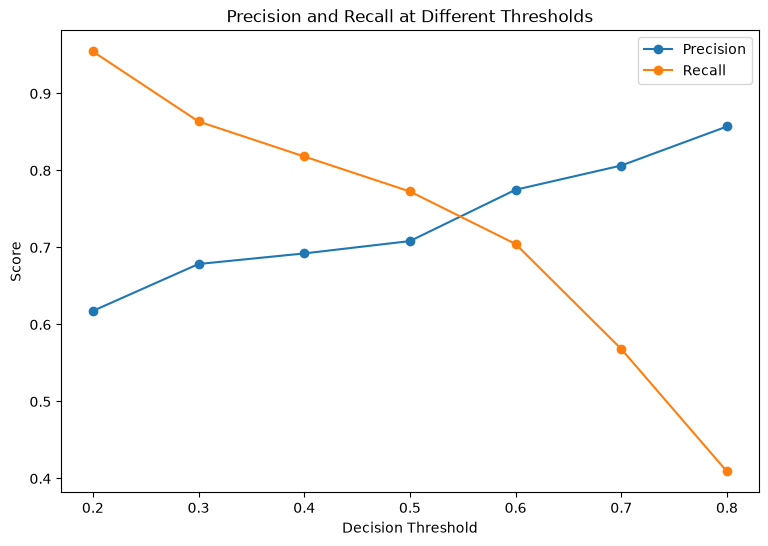

In [29]:
plt.figure(figsize=(9, 6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall at Different Thresholds")
plt.legend()

plt.show()

In [30]:
print("Class 0 covariance:")
print(cov_0)

print("\nClass 1 covariance:")
print(cov_1)

Class 0 covariance:
[[ 1.00577228  0.12363825  0.20996939  0.19698606  0.32629347  0.32536831
   0.02342289  0.15606613  0.15113281  0.21480717]
 [ 0.12363825  1.00417992  0.06979475  0.23115662 -0.03379387  0.15897518
  -0.46965275  0.34004032  0.01897105  0.18378529]
 [ 0.20996939  0.06979475  0.63929539  0.15496757  0.29620589  0.37157952
  -0.27284332  0.35028591  0.2568912   0.2497612 ]
 [ 0.19698606  0.23115662  0.15496757  0.68824173  0.16331268  0.18538182
  -0.08654602  0.12654012  0.13359028  0.28630489]
 [ 0.32629347 -0.03379387  0.29620589  0.16331268  0.99100361  0.92460279
   0.10292657  0.49791653  0.45016011  0.23351869]
 [ 0.32536831  0.15897518  0.37157952  0.18538182  0.92460279  1.0587859
  -0.25268199  0.6961649   0.34203454  0.25076411]
 [ 0.02342289 -0.46965275 -0.27284332 -0.08654602  0.10292657 -0.25268199
   1.07934732 -0.66000931 -0.25078355 -0.16323416]
 [ 0.15606613  0.34004032  0.35028591  0.12654012  0.49791653  0.6961649
  -0.66000931  0.81421916  0.4262

In [31]:
covariance_difference = np.linalg.norm(cov_0 - cov_1)

print("Covariance difference:", covariance_difference)

Covariance difference: 1.2244603438317427


In [32]:
print("Determinant of covariance 0:", np.linalg.det(cov_0))
print("Determinant of covariance 1:", np.linalg.det(cov_1))

Determinant of covariance 0: 7.449311671622903e-05
Determinant of covariance 1: 0.0002950630226958562


In [33]:
logistic = LogisticRegression(max_iter=1000)

logistic.fit(X_train_scaled, y_train)

y_pred_logistic = logistic.predict(X_test_scaled)
y_prob_logistic = logistic.predict_proba(X_test_scaled)[:, 1]

In [34]:
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
logistic_precision = precision_score(y_test, y_pred_logistic)
logistic_recall = recall_score(y_test, y_pred_logistic)
logistic_f1 = f1_score(y_test, y_pred_logistic)
logistic_auc = roc_auc_score(y_test, y_prob_logistic)

print("Logistic Regression")
print("Accuracy :", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall   :", logistic_recall)
print("F1 Score :", logistic_f1)
print("ROC-AUC  :", logistic_auc)

Logistic Regression
Accuracy : 0.7415730337078652
Precision: 0.7142857142857143
Recall   : 0.7954545454545454
F1 Score : 0.7526881720430108
ROC-AUC  : 0.8262626262626263


In [35]:
comparison = pd.DataFrame({
    "Model": ["LDA", "Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lda),
        accuracy_score(y_test, y_pred_logistic)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lda),
        precision_score(y_test, y_pred_logistic)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lda),
        recall_score(y_test, y_pred_logistic)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lda),
        f1_score(y_test, y_pred_logistic)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lda),
        roc_auc_score(y_test, y_prob_logistic)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,LDA,0.730337,0.708333,0.772727,0.739130,0.828788
1,Logistic Regression,0.741573,0.714286,0.795455,0.752688,0.826263


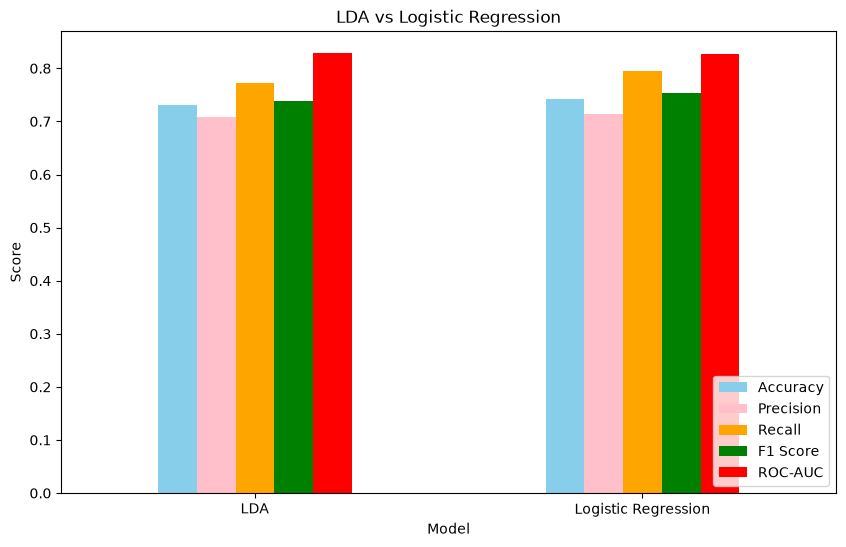

In [36]:
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6),
    color=["skyblue", "pink","orange","green","red"]
)

plt.ylabel("Score")
plt.title("LDA vs Logistic Regression")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()